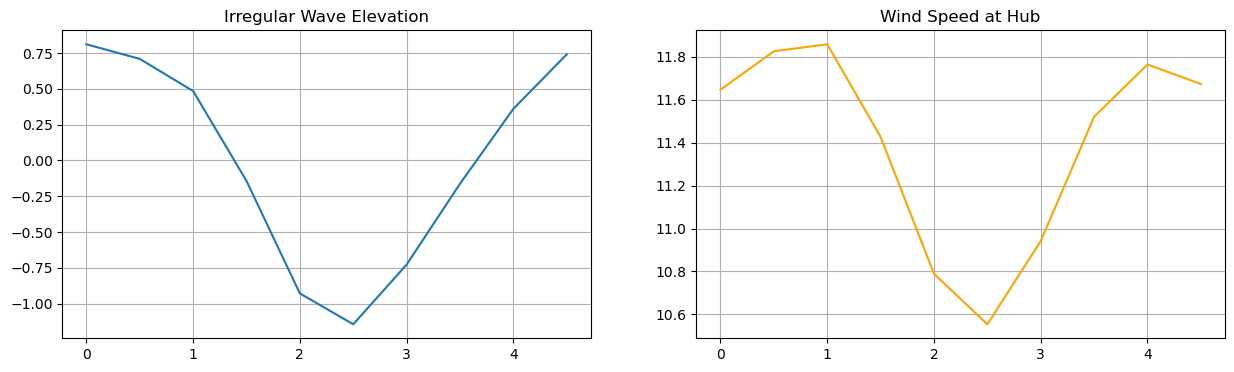

In [66]:
# ==============================================================================
# CELL 1: IMPORTS & ENVIRONMENTAL GENERATION (WAVES AND WIND)
# ==============================================================================
"""
DESCRIPTION:
This cell handles module imports and generates the time-series for environmental loads (waves and wind).

PHYSICS:
- Waves: Generates irregular waves using a JONSWAP spectrum. Computes wave kinematics (velocity, acceleration, and dynamic pressure) based on linear (Airy) wave theory.
- Wind: Generates a turbulent wind time-series using the Kaimal spectrum.

INPUTS & ASSUMPTIONS (CHECK THESE VALUES):
- `seed = 3` : Random seed for repeatable phase generation.
- `timeInfo` : Time simulation parameters -> TTrans=50s, TDur=501s, dt=0.5s, fHighCut=0.5Hz.
- `wind` : Wind parameters -> Turbulence intensity (I=0.14), integral length scale (l=340.2m), mean wind speed (V_10=8.0 m/s).
- `wave` : Wave parameters -> Significant wave height (Hs=7.5m), peak period (Tp=11s), gamma=1.0, water depth (h=320m).
- `g = 9.81` : Gravity acceleration (hardcoded in `dispersion` and `calculateKinematicsFFT`).
- `rho_water = 1025.0` : Water density (hardcoded in `calculateKinematicsFFT`).

OUTPUTS:
- `waves` dict: Time-series of elevation (`eta`), velocity (`u`), acceleration (`ut`), and pressure (`phi`).
- `wind` dict: Time-series of wind speed (`V_hub`).

NUMERICAL METHODS:
- (Inverse_ Fast Fourier Transform ((I)FFT) is used to efficiently convert frequency-domain spectra to the time domain.
- Newton-Raphson method (`scipy.optimize.root_scalar`) is used to solve the implicit wave dispersion equation.
- Linear Congruential Generator (LCG) is used to generate pseudo-random phases.
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
from scipy.fft import fft 
import scipy.integrate as scp
import time


start_time = time.time()

# --- WAVE & WIND FUNCTIONS ---
def lcg(seed, a=1103515245, c=12345, m=2**31, n=1):
    """Linear congruential random number generator (matches MATLAB)."""
    numbers = np.ones(n) * seed
    for i in range(1, n):
        numbers[i] = (a * numbers[i-1] + c) % m
    return 2*np.pi*np.array([x / m for x in numbers])  # Normalize to [0, 1]

def calculateJONSWAPSpectrum(waveDict):
    Hs, Tp = waveDict["Hs"], waveDict["Tp"]
    gamma = waveDict.get("gamma", 1.0)
    df = waveDict["TDur"]**-1.0
    f = np.arange(df, waveDict["fHighCut"] + df, df)
    sigma = np.ones(len(f))
    fp = 1./Tp
    sigma[f>fp] = 0.09
    sigma[f<=fp] = 0.07        
    Spectrum = 0.3125 * Hs**2 * Tp * (f / fp)**(-5) * np.exp(-1.25 * (f / fp)**(-4)) * \
               (1 - 0.287 * np.log(gamma)) * gamma**(np.exp(-0.5 * (((f/fp) - 1) / sigma)**2)) 
    
    out = dict(waveDict)
    out.update({"Spectrum": Spectrum, "amplitudeSpectrum": np.sqrt(2*Spectrum*df), "f": f})
    return out

def generateRandomPhases(inputDict, seed=3):
    phi = lcg(seed, n=len(inputDict["Spectrum"]))
    out = dict(inputDict)
    out["randomPhases"] = phi
    return out

def dispersion(f, h):
    omega = 2*np.pi*f
    k = np.zeros_like(f)
    g = 9.81
    myFun = lambda k, omega, g, h: omega**2 - g*k*np.tanh(k*h)
    myFunPrime = lambda k, omega, g, h: -g*(k*h*(1-np.tanh(k*h)**2)+np.tanh(k*h))
    kGuess = omega[0] / np.sqrt(g*h)
    for j in range(len(f)):
        k[j] = root_scalar(lambda x: myFun(x,omega[j],g,h), fprime=lambda x: myFunPrime(x,omega[j], g,h), x0=kGuess, method='newton').root
        kGuess = k[j]
    return k

def pad2(vector, size):
    return np.pad(vector, [1, size - len(vector) - 1])

def calculateFreeSurfaceElevationTimeSeriesFFT(waveDict):
    t = waveDict["t"]
    M = len(t)
    kernel = waveDict["amplitudeSpectrum"] * np.exp(1j * waveDict["randomPhases"])
    eta = np.fft.ifft(pad2(kernel, M)).real * M
    out = dict(waveDict)
    out.update({"t": t, "eta": eta})
    return out

def calculateKinematicsFFT(inputDict):
    t, f, h, z = inputDict["t"], inputDict["f"], inputDict["h"], inputDict["z"]
    omega = 2*np.pi*f
    u, ut, phi = np.zeros((len(t), len(z))), np.zeros((len(t), len(z))), np.zeros((len(t), len(z)))
    k = dispersion(f, h)
    M = len(t)
    
    for j_, z_ in enumerate(z):
        cosh_term = np.cosh(k*(z_ + h)) / np.sinh(k * h)
        uKernel = inputDict["amplitudeSpectrum"] * omega * cosh_term * np.exp(1j*inputDict["randomPhases"])
        u[:, j_] = np.fft.ifft(pad2(uKernel, M)).real * M
        utKernel = inputDict["amplitudeSpectrum"] * omega**2 * cosh_term * np.exp(1j*(inputDict["randomPhases"] + (np.pi/2)))
        ut[:, j_] = np.fft.ifft(pad2(utKernel, M)).real * M
        pKernel = -1025.0 * inputDict["amplitudeSpectrum"] * 9.81 * cosh_term * np.exp(1j*inputDict["randomPhases"])
        phi[:, j_] = np.fft.ifft(pad2(pKernel, M)).real * M
        
    out = dict(inputDict)
    out.update({"u": u, "ut": ut, "phi": phi})
    return out

def calculateKaimalSpectrum(windDict):
    df = windDict["TDur"]**-1
    f = np.arange(df, windDict["fHighCut"], df)
    Spectrum = (4 * windDict["I"]**2 * windDict["V_10"] * windDict["l"]) / (1 + 6 * ((f * windDict["l"])/windDict["V_10"]))**(5/3)
    out = dict(windDict)
    out.update({"Spectrum": Spectrum, "amplitudeSpectrum": np.sqrt(2*Spectrum*df), "f": f})
    return out

def calculateWindTimeSeriesFFT(windDict):
    t = windDict["t"]
    M = len(t)
    kernel = windDict["amplitudeSpectrum"] * np.exp(1j * windDict["randomPhases"])
    V_hub = np.fft.ifft(pad2(kernel, M)).real * M + windDict["V_10"]
    out = dict(windDict)
    out.update({"t": t, "V_hub": V_hub})
    return out

# --- DICTIONARIES & GENERATION ---
timeInfo = {"TTrans":50, "TDur":5, "dt":0.5, "fHighCut":0.5}
wind = {"I": 0.14, "l": 340.2, "V_10": 11.4}
wave = {"Hs": 9.14, "Tp": 13.6, "gamma": 1.0, "h": 320, "z": np.arange(-320, 1, 1)}

# Generate Waves
wave.update(timeInfo)
wave["t"] = np.arange(0, wave["TDur"], wave["dt"])
waves = calculateKinematicsFFT(calculateFreeSurfaceElevationTimeSeriesFFT(generateRandomPhases(calculateJONSWAPSpectrum(wave), seed=3)))
# WAVE GENERATION (Executes from the inside -> out):
# 1. calculateJONSWAPSpectrum: Creates the wave energy spectrum (frequency domain) based on Hs and Tp.
# 2. generateRandomPhases: Assigns random phases to the spectrum frequencies so the wave is irregular (seed=3 ensures repeatability).
# 3. calculateFreeSurfaceElevationTimeSeriesFFT: Uses IFFT to convert the spectrum & phases into a time-series surface elevation.
# 4. calculateKinematicsFFT: Takes the elevation data and calculates sub-surface velocity, acceleration, and pressure.


# Generate Wind
wind.update(timeInfo)
wind["t"] = waves["t"]
wind = calculateWindTimeSeriesFFT(generateRandomPhases(calculateKaimalSpectrum(wind)))
# WIND GENERATION (Executes from the inside -> out):
# 1. calculateKaimalSpectrum: Creates the turbulent wind energy spectrum.
# 2. generateRandomPhases: Assigns random phases for realistic, repeatable wind gusts.
# 3. calculateWindTimeSeriesFFT: Uses IFFT to convert the spectrum into a time-series wind speed.


# Plotting Environments
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
axs[0].plot(waves["t"], waves["eta"])
axs[0].set_title("Irregular Wave Elevation")
axs[0].grid()
axs[1].plot(wind["t"], wind["V_hub"], color='orange')
axs[1].set_title("Wind Speed at Hub")
axs[1].grid()
plt.show()

In [67]:
# ==============================================================================
# CELL 2: MOORING & THRUST LOOKUP TABLES
# ==============================================================================
"""
DESCRIPTION:
This cell defines lookup tables for the mooring line restoring forces and the aerodynamic rotor thrust.

PHYSICS:
- Mooring System: Non-linear restoring forces and moments provided by the mooring lines as a function of the horizontal excursion (surge/sway).
- Rotor Thrust: Aerodynamic thrust force exerted by the wind on the rotor as a function of relative wind speed.

INPUTS & ASSUMPTIONS (CHECK THESE VALUES):
- `mooring_offset` : Array of horizontal excursions (0 to 31.48 m).
- `mooring_table` : 4x31 array containing reaction forces (Fxl, Fzl, Fxr, Fzr) corresponding to the offsets. Note: `Fzl` and `Fzr` are zeroed out at the initial offset.
- `thrust_table` : Mapping of wind speeds (0 to 24 m/s) to aerodynamic thrust forces (0 to 807.76 kN).
- Assumption: The mooring forces (Fx, Fz) can be linearly interpolated for any given offset within the bounds.
- Assumption: The aerodynamic thrust is solely a function of the instantaneous relative wind speed at hub height.

OUTPUTS:
- `Fmoor(x)` function: Returns the mooring forces (fxl, fzl, fxr, fzr) for a given horizontal displacement `x`.

NUMERICAL METHODS:
- 1D Linear Interpolation (`np.interp`) is used to sample forces from the discrete lookup tables.
"""
# Mooring Table [offset -> Fxl, Fzl, Fxr, Fzr]
mooring_offset = np.array([0, 3.49, 7.28, 10.15, 12.31, 13.9, 15.12, 16.23, 17.15, 17.98, 18.74, 19.5, 20.22, 20.89, 21.54, 22.19, 22.85, 23.5, 24.13, 24.75, 25.38, 25.97, 26.59, 27.22, 27.84, 28.44, 29.05, 29.67, 30.25, 30.86, 31.48])
mooring_table = np.array([
    [  -301446.60422046,   -337379.97696724,   -397387.39134888,
           -470825.79506973,   -556149.09198733,   -645566.18232553,
           -734675.91644729,   -833331.58786685,   -927824.59341565,
          -1022160.27303207,  -1115123.41246619,  -1213381.04277708,
          -1310492.89336254,  -1403732.66190896,  -1496351.12914373,
          -1590714.92691488,  -1687995.05852086,  -1784986.08038156,
          -1879919.1421873 ,  -1974086.30735597,  -2070403.15388061,
          -2161091.87614698,  -2256823.13777638,  -2354484.90199056,
          -2450921.91636201,  -2544512.82574782,  -2639895.02460998,
          -2737049.1603971 ,  -2828101.84453703,  -2924017.01692269,
          -3021646.51348997],
    [ -2687887.6881004 ,  -3008292.26007346,  -3543356.14221022,
          -4198179.18029181,  -4958975.40782282,  -5756274.47459234,
          -6550832.95985101,  -7430509.03135846,  -8273068.15350561,
          -9114224.45860071,  -9943142.33139713, -10819269.21780724,
         -11685179.61090095, -12516564.08300457, -13342408.64149557,
         -14183815.66575911, -15051226.55836705, -15916059.5664874 ,
         -16762542.50724299, -17602196.23143975, -18461017.86786101,
         -19269655.60541224, -20123255.79827353, -20994069.56745934,
         -21853962.69605002, -22688478.16092576, -23538965.8904145 ,
         -24405253.32498528, -25217136.37572034, -26072376.4326589 ,
         -26942902.48319188],
    [   315260.63321602,    249492.94265727,    212009.35746419,
            185368.97616291,    164951.50323532,    158680.01225458,
            146983.8736424 ,    145386.5577522 ,    140036.26571395,
            131021.36772318,    128771.53864654,    128483.45088051,
            126479.43383186,    122553.74594811,    115161.93944128,
            113569.01718244,    113591.64593374,    112059.3185329 ,
            108700.09507975,    107329.48739852,    106005.16000889,
             99718.59121803,     98526.4269766 ,     95561.12345436,
             94435.99487228,     94568.53430948,     93484.5713484 ,
             92433.88998479,     86963.23910028,     86009.09242459,
             83442.96785211],
    [ -2693198.75156988,  -2395404.24379817,  -2141648.22777307,
          -1975535.7058066 ,  -1865967.23116873,  -1789537.39082219,
          -1736371.80912458,  -1688767.71969355,  -1651371.05794757,
          -1619547.19064498,  -1591737.18969765,  -1562691.06139977,
          -1538317.03106865,  -1514335.98708205,  -1492701.74259595,
          -1472054.66211854,  -1449827.49668397,  -1430269.62883724,
          -1410625.81525124,  -1392839.12816227,  -1375653.03092578,
          -1358563.91305217,  -1342321.8934142 ,  -1324478.49555594,
          -1308884.19781405,  -1292147.63910165,  -1277336.79116733,
          -1262980.69002487,  -1248574.86145418,  -1234875.69884554,
          -1219926.43058645]
])
mooring_table[1] -= mooring_table[1][0]
mooring_table[3] -= mooring_table[3][0]

def Fmoor(x):
    fxl = np.interp(x, mooring_offset, mooring_table[0])
    fzl = np.interp(x, mooring_offset, mooring_table[1])
    fxr = np.interp(x, mooring_offset, mooring_table[2])
    fzr = np.interp(x, mooring_offset, mooring_table[3])
    return fxl, fzl, fxr, fzr

# Thrust Table
thrust_table = {
    "x": [0, 3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24],
    "y": [0, 173.91, 217.61, 284.44, 348.28, 395.25, 479.78, 589.49, 702.76, 807.76, 692.91, 611.48, 543.47, 521.73, 499.71, 456.31, 435.26, 434.44, 413.38, 391.58, 391.30, 390.11, 349.40]
}

In [68]:
# ==============================================================================
# CELL 3: STRUCTURAL PROPERTIES (TOWER, RNA, BUOY)
# ==============================================================================
"""
DESCRIPTION:
This cell defines the geometry, mass, and stiffness properties of the offshore wind turbine structure (Tower, Rotor-Nacelle-Assembly (RNA), and Buoy).

PHYSICS:
- Structural dynamics parameters defined for distributed masses (tower, buoy) and point masses (RNA).
- Defines centers of gravity (COG) and rotational inertias.
- Substructure (buoy) consists of a cylindrical upper part, a tapered section, and a cylindrical base. Ballast mass is calculated to achieve the target total mass.

INPUTS & ASSUMPTIONS (CHECK THESE VALUES):
- Material properties: Young's Modulus `E = 210e9` Pa, Shear Modulus `G = 80.8e9` Pa, steel density `rho = 8500` kg/m^3 which is somewhat higher than typical values to account for the "smeared" mass of welds, stiffeners, and paint, water density `rho_water = 1025` kg/m^3, `g = 9.81` m/s^2.
- Current force: `Fcurrent_avg = 1797` N/m (assumed uniform).
- Tower properties: Diameters (`D_base=6.5m`, `D_top=3.87m`), thicknesses (`t_base=0.027m`, `t_top=0.019m`), elevations (10m to 87.6m). Linear taper is assumed.
- RNA properties: Hub height (`H_hub=90m`), offset (`u_offset=5m`), masses (`m_hub=56780kg`, `m_blade=17740kg`, `m_nacelle=240000kg`), blade inertia (`I_blade=11776047` kg-m^2).
- Buoy properties: Draft (`draft=-120m`), elevation to top (`z_top_buoy=10m`), diameters (`D_above_buoy=6.5m`, `D_below_buoy=9.4m`), total mass (`m_buoy=7466330kg`), overall COG (`cog_buoy=-89.9155m`), uniform thickness (`0.0365m`).
- Assumption: Internal ballast extends upwards from the bottom of the buoy to match the total required mass and overall COG.

OUTPUTS:
- Continuous/nodal structural profiles: `rA_tower`, `EI_tower`, `EA_tower`, `rI_tower`.
- RNA point mass (`m_RNA`) and inertia (`I55_RNA`).
- Computed ballast height (`H_ballast`) and density (`rho_ballast`).

NUMERICAL METHODS:
- Numerical integration (`np.trapz`) is used to compute the shell mass, volume, and center of mass along the discretized buoy sections.
- Linear interpolation (`np.interp`) maps tabulated properties to the discretized nodes.
"""
# Basic Constants
E, G = 210e9, 80.8e9   # [Pa]
rho, rho_water = 8500, 1025 # [kg/m^3]
g = 9.81
Fcurrent_avg = 1797

# --- TOWER PROPERTIES ---
elev_tower = np.array([10.0, 17.76, 25.52, 33.28, 41.04, 48.80, 56.56, 64.32, 72.08, 79.84, 87.60])
rA = np.array([4667.0, 4345.28, 4034.76, 3735.44, 3447.32, 3170.40, 2904.69, 2650.18, 2406.88, 2174.77, 1953.87])
EI = np.array([603.9e9, 517.6e9, 440.9e9, 373.0e9, 313.2e9, 260.8e9, 215.3e9, 176.0e9, 142.3e9, 113.6e9, 89.4e9])
EA = np.array([115.3e9, 107.3e9, 99.6e9, 92.2e9, 85.1e9, 78.3e9, 71.7e9, 65.4e9, 59.4e9, 53.7e9, 48.2e9])
rI = np.array([24443.7, 20952.2, 17847.0, 15098.5, 12678.6, 10560.1, 8717.2, 7124.9, 5759.8, 4599.3, 3622.1])

D_base, t_base = 6.5, 0.027
D_top, t_top = 3.87, 0.019
nel_tower = 15
nn_tower = nel_tower + 1
z_base, z_top = 10, 87.6

z_tower = np.linspace(z_base, z_top, nel_tower)
zn_tower = np.linspace(z_base, z_top, nn_tower)

rA_tower = np.interp(z_tower, elev_tower, rA)
EI_tower = np.interp(z_tower, elev_tower, EI)
EA_tower = np.interp(z_tower, elev_tower, EA)
rI_tower = np.interp(z_tower, elev_tower, rI)
D_tower = np.linspace(D_base, D_top, nel_tower)
R_tower = D_tower / 2
rAw_tower = rho_water * np.pi * R_tower**2

# --- RNA PROPERTIES ---
H_hub, u_offset = 90, 5
m_hub, m_blade, m_nacelle = 56780, 17740, 240000
I_blade = 11776047          #kg m^2

m_RNA = m_hub + m_nacelle + 3*m_blade
cog_hub = np.array([u_offset, 0, H_hub])
cog_blade = np.array([u_offset, 0, H_hub])
cog_nacelle = np.array([-1.9, 0, H_hub])
cog_RNA = (m_hub*cog_hub + m_nacelle*cog_nacelle + 3*m_blade*cog_blade) / m_RNA
I55_RNA = m_RNA*(cog_RNA[0]**2 + (H_hub - z_top)**2) + 2*I_blade        #actually should be 1.5*blade but 2 for safety

# --- BUOY PROPERTIES ---
draft, z_top_buoy = -120, 10
z_top_taper_buoy, z_base_taper_buoy = -4, -12
D_above_buoy, D_below_buoy = 6.5, 9.4
H_taper_buoy = np.abs(z_top_taper_buoy - z_base_taper_buoy)
taper_slope_buoy = (D_below_buoy - D_above_buoy) / H_taper_buoy

m_buoy = 7466330        #kg
cog_buoy = -89.9155     #m

zn_range = np.array([draft, z_base_taper_buoy, z_top_taper_buoy, 0, z_top_buoy])
R_buoy_key = np.array([D_below_buoy/2, D_below_buoy/2, D_above_buoy/2, D_above_buoy/2, D_above_buoy/2])

# Dynamically calculate the wall thickness based on the known shell mass
m_shell_target = 1135557
I_R = np.trapz(2 * R_buoy_key, zn_range)
L = np.trapz(np.ones_like(zn_range), zn_range)

# Solve quadratic: (rho * np.pi * L)*t^2 - (rho * np.pi * I_R)*t + m_shell_target = 0
a_quad = rho * np.pi * L
b_quad = -rho * np.pi * I_R
t_buoy_val = (-b_quad - np.sqrt(b_quad**2 - 4 * a_quad * m_shell_target)) / (2 * a_quad)
print(f"Calculated buoy wall thickness: {t_buoy_val:.5f} m")

t_buoy_key = np.ones_like(zn_range) * t_buoy_val

A_buoy_key = np.pi*(R_buoy_key**2 - (R_buoy_key-t_buoy_key)**2)
V0_buoy = np.trapz(np.pi*R_buoy_key**2, zn_range) - np.pi*R_buoy_key[-1]**2*z_top_buoy

rA_buoy_key = rho * A_buoy_key
CM_shell = np.trapz(rA_buoy_key*zn_range, zn_range) / np.trapz(rA_buoy_key, zn_range)

m_shell = np.trapz(rA_buoy_key, zn_range)
m_total = m_buoy - m_RNA
m_ballast = m_total - m_shell
CM_ballast = (cog_buoy*m_total - m_shell*CM_shell) / m_ballast
H_ballast = 2*(CM_ballast - zn_range[0])
V_ballast = H_ballast*np.pi*(R_buoy_key[0]-t_buoy_key[0])**2
rho_ballast = m_ballast / V_ballast
rA_ballast_val = rho_ballast*np.pi*(R_buoy_key[0]-t_buoy_key[0])**2

Calculated buoy wall thickness: 0.03650 m


In [69]:
# ==============================================================================
# CELL 4: DISCRETIZATION AND PROPERTY MAPPING
# ==============================================================================
"""
DESCRIPTION:
This cell handles the spatial discretization (meshing) of the structural domain (buoy + tower) for the Finite Element Method (FEM) and maps the physical properties to this mesh.

PHYSICS:
- The continuous structure is divided into discrete beam/rod elements.
- Geometrical properties (radius, area, inertia) and mass/stiffness profiles are evaluated for each discrete element.

INPUTS & ASSUMPTIONS (CHECK THESE VALUES):
- `nel_buoy = 15` : Target number of elements for the buoy.
- `zn_range_fill` : Key geometric transition elevations `[draft, draft+H_ballast, z_base_taper_buoy, z_top_taper_buoy, 0, z_top_buoy]`.
- Assumption: Property values for each element are evaluated at the midpoint of the element (`(zn_buoy[:-1] + zn_buoy[1:])/2`).
- Assumption: The structural thickness of the buoy is uniform `t_buoy = 0.0365` m.

OUTPUTS:
- Mapped element properties: `R_buoy`, `rA_buoy`, `rI_buoy`, `A_buoy`, `I_buoy`, `EA_buoy`, `EI_buoy`.
- Combined global arrays for the entire structure: `zn` (nodes), `rA`, `rI`, `rAw`, `EI`, `EA`, `Rs`.
- Element-node connectivity lists: `elem_nodes`, `elem_dofs`, `dof_node`.
- `Fair_idx` : The index of the fairlead connection (closest to z = -70m).

NUMERICAL METHODS:
- A custom meshing algorithm (`interpolate_nodes_preserving_keys`) proportionally distributes elements between hardpoints (key geometric elevations) ensuring no element bridges a geometric discontinuity.
"""
def interpolate_nodes_preserving_keys(zn_range, total_nodes):
    total_segments = total_nodes - 1
    seg_lengths = np.diff(zn_range)
    raw_segments = seg_lengths / np.sum(seg_lengths) * total_segments
    seg_counts = np.round(raw_segments).astype(int)
    
    while np.sum(seg_counts) != total_segments:
        diff = total_segments - np.sum(seg_counts)
        idx = np.argmax(raw_segments - seg_counts if diff > 0 else seg_counts - raw_segments)
        seg_counts[idx] += np.sign(diff)

    zn = []
    for i in range(len(zn_range) - 1):
        zn.extend(np.linspace(zn_range[i], zn_range[i+1], seg_counts[i] + 1, endpoint=False))
    zn.append(zn_range[-1])
    return np.array(zn)

nel_buoy = 15
nn_buoy = nel_buoy + 1
zn_range_fill = [draft, draft+H_ballast, z_base_taper_buoy, z_top_taper_buoy, 0, z_top_buoy]
zn_buoy = interpolate_nodes_preserving_keys(zn_range_fill, nn_buoy)
nel_buoy = len(zn_buoy) - 1

R_buoy_interp, rA_buoy_interp, rI_buoy_interp = np.zeros(nel_buoy), np.zeros(nel_buoy), np.zeros(nel_buoy)
t_buoy = np.ones(nel_buoy)*0.0365

for i, z in enumerate((zn_buoy[:-1] + zn_buoy[1:])/2):
    if z < draft + H_ballast:
        rA_buoy_interp[i] = rA_buoy_key[0] + rA_ballast_val
        R_buoy_interp[i] = R_buoy_key[0]
        rI_buoy_interp[i] = rho*np.pi/4*(R_buoy_key[0]**4 - (R_buoy_key[0]-0.0365)**4) + np.pi/4*rho_ballast*(R_buoy_key[0] - 0.0365)**4
    elif z <= z_base_taper_buoy:
        rA_buoy_interp[i], R_buoy_interp[i] = rA_buoy_key[1], R_buoy_key[1]
        rI_buoy_interp[i] = rho*np.pi/4*(R_buoy_key[1]**4 - (R_buoy_key[1]-0.0365)**4)
    elif z <= z_top_taper_buoy:
        R_buoy_interp[i] = (D_below_buoy - taper_slope_buoy * (z - z_base_taper_buoy)) / 2
        rA_buoy_interp[i] = np.interp(z, zn_range_fill[1:], rA_buoy_key)
        rI_buoy_interp[i] = rho*np.pi/4*(R_buoy_interp[i]**4 - (R_buoy_interp[i]-0.0365)**4)
    else:
        R_buoy_interp[i] = D_above_buoy / 2
        rA_buoy_interp[i] = rA_buoy_key[2]
        rI_buoy_interp[i] = rho*np.pi/4*(R_buoy_key[-1]**4 - (R_buoy_key[-1]-0.0365)**4)

R_buoy, rA_buoy, rI_buoy = R_buoy_interp, rA_buoy_interp, rI_buoy_interp
A_buoy = np.pi*(R_buoy**2 - (R_buoy - t_buoy)**2)
I_buoy = np.pi/4*(R_buoy**4 - (R_buoy - t_buoy)**4)
EA_buoy, EI_buoy = E*A_buoy, E*I_buoy
rAw_buoy = rho_water*np.pi*R_buoy**2

# Combine Buoy and Tower (has a standard tolerance of 1e-5 m for node matching)
if np.isclose(zn_buoy[-1], zn_tower[0]):
    zn = np.append(zn_buoy[:-1], zn_tower)
else:
    zn = np.append(zn_buoy, zn_tower)

ne, nn = len(zn)-1, len(zn)
Fair_idx = np.argmin(np.abs(zn - (-70)))

elem_nodes = [[ie, ie+1] for ie in range(ne)]
elem_dofs = [np.arange(3*ie, 3*ie+6) for ie in range(ne)]
dof_node = [int(np.floor(idof / 3)) for idof in range(3*nn)]

rA, rI, rAw = np.append(rA_buoy, rA_tower), np.append(rI_buoy, rI_tower), np.append(rAw_buoy, rAw_tower)
EI, EA, Rs = np.append(EI_buoy, EI_tower), np.append(EA_buoy, EA_tower), np.append(R_buoy, R_tower)

In [70]:
# ==============================================================================
# CELL 5: FINITE ELEMENT SHAPE FUNCTIONS
# ==============================================================================
"""
DESCRIPTION:
This cell defines the polynomial shape functions and their derivatives used for the Finite Element (FE) formulation of the structure.

PHYSICS:
- Rod Elements: Model axial (heave) displacements using linear shape functions (2 DOFs per element).
- Euler-Bernoulli Beam Elements: Model transverse (surge/pitch) deflections using cubic Hermitian shape functions (4 DOFs per element).

INPUTS & ASSUMPTIONS (CHECK THESE VALUES):
- `h` : Array of element lengths extracted from node coordinates `zn`.
- Assumption: Linear interpolation is sufficient for axial deformation.
- Assumption: Cubic interpolation accurately captures transverse bending without shear deformation (Euler-Bernoulli assumption).

OUTPUTS:
- Rod shape functions and 1st derivatives: `N_rod`, `dN_rod`.
- Beam shape functions, 1st and 2nd derivatives: `N_k_b`, `dN_k_b`, `ddN_k_b`.

NUMERICAL METHODS:
- Standard Finite Element Method (FEM) spatial discretization.
- Shape function coefficients for the beam are determined by solving a 4x4 linear system (`np.linalg.solve`) applying unit displacement/rotation boundary conditions at the element nodes.
"""
h = np.diff(zn)
N_rod, dN_rod = [], []

for ie in range(ne):
    h_local = h[ie]
    ze = zn[elem_nodes[ie]]
    N_rod.append([lambda z, ze=ze, h=h_local: (ze[1] - z) / h, lambda z, ze=ze, h=h_local: (z - ze[0]) / h])
    dN_rod.append([lambda z, h=h_local: -1 / h + 0.0 * z, lambda z, h=h_local: 1 / h + 0.0 * z])

def base(z, h_loc): return np.array([[1], [z], [z**2], [z**3]]) if isinstance(z, float) else np.array([[np.ones(len(z))], [z], [z**2], [z**3]])
def dbase(z, h_loc): return np.array([[0], [1], [2 * z], [3 * z**2]]) if isinstance(z, float) else np.array([[np.zeros(len(z))], [np.ones(len(z))], [2 * z], [3 * z**2]])
def ddbase(z, h_loc): return np.array([[0], [0], [2], [6 * z]]) if isinstance(z, float) else np.array([[np.zeros(len(z))], [np.zeros(len(z))], [2*np.ones(len(z))], [6 * z]])

def make_N(coeff, h_loc): return lambda z: np.dot(np.transpose(base(z, h_loc)), coeff)
def make_dN(coeff, h_loc): return lambda z: np.dot(np.transpose(dbase(z, h_loc)), coeff)
def make_ddN(coeff, h_loc): return lambda z: np.dot(np.transpose(ddbase(z, h_loc)), coeff)

N_k_b, dN_k_b, ddN_k_b = [], [], []
for ie in range(ne):
    h_loc = h[ie]
    matrix = np.array([[1, 0, 0, 0], [0, 1, 0, 0], [1, h_loc, h_loc**2, h_loc**3], [0, 1, 2 * h_loc, 3 * h_loc**2]])
    N_k_el, dN_k_el, ddN_k_el = [], [], []
    for idof in range(4):
        rhs = np.zeros(4); rhs[idof] = 1
        coeff = np.linalg.solve(matrix, rhs)
        N_k_el.append(make_N(coeff, h_loc))
        dN_k_el.append(make_dN(coeff, h_loc))
        ddN_k_el.append(make_ddN(coeff, h_loc))
    N_k_b.append(N_k_el)
    dN_k_b.append(dN_k_el)
    ddN_k_b.append(ddN_k_el)

In [71]:
# ==============================================================================
# CELL 6: GLOBAL MATRIX ASSEMBLY (OPTIMIZED)
# ==============================================================================
"""
DESCRIPTION:
WHAT THIS CODE DOES:
1. Calculates the cumulative structural tension (T_self) caused by gravity acting on the tower mass.
2. Integrates the FEM shape functions to build 4x4 Bending Matrices (Surge/Pitch) and 2x2 Axial Matrices (Heave).
3. Directly injects these local matrices into the global M, K, Q, H, D, and I matrices using np.ix_.
4. Applies specific boundary conditions (RNA Mass, Heave Damping) directly to the top and bottom global DOFs.

PHYSICS:
- Structural Stiffness (`Kb`, `Kr`): Includes elastic bending/axial stiffness and geometric stiffness (stress stiffening) due to cumulative self-weight/tension (`T_self`).
- Structural Mass (`Mb`, `Mr`): Consistent mass matrix formulation.
- Hydrodynamics (Morison's Equation): Computes Added Mass (`Ib`), linear/quadratic Drag (`Db`), and Hydrostatic Restoring (`Rb`).
- Boundary Conditions: Adds the RNA point mass and inertia at the top node. Adds heave hydrostatic stiffness (`C33`) and linear damping at the buoy base.

INPUTS & ASSUMPTIONS (CHECK THESE VALUES):
- Hydrodynamic coefficients: Added mass coefficient `Ca = 0.969954`, Drag coefficient `Cd = 0.6`.
- Bottom Heave Damping: `D[1, 1] += 130000` Ns/m (tuning parameter).
- RNA Destabilizing force: Cross-coupling added to global `Q` matrix.
- Rayleigh Damping: `C = 0.01 * M + 0.01 * K` (1% mass and stiffness proportional damping).
- Assumption: Small deflections are assumed for the evaluation of element integrals.

OUTPUTS:
- Global State Matrices: `M` (Mass + Added Mass), `K` (Stiffness - Destabilizing Gravity + Hydrostatic Restoring), `C` (Structural Rayleigh Damping), `D` (Hydrodynamic Drag), `Q` and `H_mat`.
- `L_cur`: Global steady current force vector.

NUMERICAL METHODS:
- Gauss-Quadrature integration (`scp.quad`) is used to numerically integrate the shape functions over each element's length to form the local matrices.
- Matrix assembly maps 4x4 and 2x2 local matrices into the global 6x6-per-element (ndofs x ndofs total) sparse-like matrices utilizing `np.ix_`.
"""

# Hydrodynamic Constants
Ca, Cd = 0.969954, 0.6
ndofs = nn * 3

# 1. Pre-allocate Global Matrices
K, M, Q, H_mat, D, I_mat = [np.zeros((ndofs, ndofs)) for _ in range(6)]
L_cur = np.zeros(ndofs)

# 2. Cumulative Tension (Self-Weight)
# Tension at any node is simply the weight of all elements strictly above it + RNA mass
elem_weight = rA * h * g
T_self = np.array([np.sum(elem_weight[i:]) + m_RNA * g for i in range(nn)])

# 3. Element Integration & Global Assembly
b_idx = [0, 2, 3, 5]  # The Surge & Pitch DOFs inside a 6-DOF element
r_idx = [1, 4]        # The Heave DOFs inside a 6-DOF element

for ie in range(ne):
    L_loc = h[ie]
    is_sub = (zn[ie + 1] <= 0)  # Boolean check: Is this element fully underwater?
    g_dofs = np.arange(3*ie, 3*ie + 6) # The 6 Global DOFs mapping to this specific element
    
    # Initialize temporary local matrices
    Mb, Kb, Fb, Rb, Db, Ib = [np.zeros((4,4)) for _ in range(6)]
    Mr, Kr = np.zeros((2,2)), np.zeros((2,2))
    
    # --- Form 4x4 Beam Matrices (Bending/Surge/Pitch) ---
    for i in range(4):
        # Current force only pushes horizontally on the Surge DOFs (indices 0 and 2 of the 4x4 beam)
        if is_sub and i in [0, 2]: 
            L_cur[g_dofs[b_idx[i]]] += scp.quad(lambda z: Fcurrent_avg * N_k_b[ie][i](z), 0, L_loc)[0]
        
        for j in range(4):
            # Structural Integrals
            Mb[i,j] = scp.quad(lambda z: rA[ie] * N_k_b[ie][i](z) * N_k_b[ie][j](z), 0, L_loc)[0]
            Kb[i,j] = scp.quad(lambda z: EI[ie] * ddN_k_b[ie][i](z) * ddN_k_b[ie][j](z) + T_self[ie] * dN_k_b[ie][j](z) * dN_k_b[ie][i](z), 0, L_loc)[0]
            Fb[i,j] = scp.quad(lambda z: rA[ie] * g * dN_k_b[ie][j](z) * N_k_b[ie][i](z), 0, L_loc)[0]
            
            # Hydrodynamic Integrals (Only if underwater)
            if is_sub: 
                Rb[i,j] = scp.quad(lambda z: rho_water * g * Rs[ie]**2 * np.pi * dN_k_b[ie][j](z) * N_k_b[ie][i](z), 0, L_loc)[0]
                Db[i,j] = scp.quad(lambda z: 0.5 * rho_water * Cd * np.pi * Rs[ie]**2 * N_k_b[ie][j](z) * N_k_b[ie][i](z), 0, L_loc)[0]
                Ib[i,j] = scp.quad(lambda z: rho_water * (1 + Ca) * np.pi * Rs[ie]**2 * N_k_b[ie][j](z) * N_k_b[ie][i](z), 0, L_loc)[0]

    # --- Form 2x2 Rod Matrices (Axial/Heave) ---
    for i in range(2):
        for j in range(2):
            Mr[i,j] = scp.quad(lambda z: rA[ie] * N_rod[ie][i](z) * N_rod[ie][j](z), zn[ie], zn[ie+1])[0]
            Kr[i,j] = scp.quad(lambda z: EA[ie] * dN_rod[ie][i](z) * dN_rod[ie][j](z), zn[ie], zn[ie+1])[0]

    # --- Direct Global Injection ---
    # np.ix_ creates an open mesh grid, dropping the local matrices instantly into the correct global slots
    M[np.ix_(g_dofs[b_idx], g_dofs[b_idx])] += Mb
    K[np.ix_(g_dofs[b_idx], g_dofs[b_idx])] += Kb
    Q[np.ix_(g_dofs[b_idx], g_dofs[b_idx])] += Fb
    H_mat[np.ix_(g_dofs[b_idx], g_dofs[b_idx])] += Rb
    D[np.ix_(g_dofs[b_idx], g_dofs[b_idx])] += Db
    I_mat[np.ix_(g_dofs[b_idx], g_dofs[b_idx])] += Ib
    
    M[np.ix_(g_dofs[r_idx], g_dofs[r_idx])] += Mr
    K[np.ix_(g_dofs[r_idx], g_dofs[r_idx])] += Kr

# 4. Apply Hard Boundary Conditions Directly to Global Array Nodes
# Top Node (RNA) -> Global DOFs: [-3]=Surge, [-2]=Heave, [-1]=Pitch
M[-3, -3] += m_RNA
M[-2, -2] += m_RNA
M[-1, -1] += I55_RNA
Q[-3, -1] -= m_RNA * g  # RNA Destabilizing force cross-coupling
Q[-1, -3] += m_RNA * g

# Bottom Node (Buoy Base) -> Global DOFs: [0]=Surge, [1]=Heave, [2]=Pitch
C33 = rho_water * np.pi * R_buoy[-1]**2 * g
K[1, 1] += C33
D[1, 1] += 130000  # Bottom Heave Damping

# 5. Finalize Global State Matrices
C = 0.01 * M + 0.01 * K  # Rayleigh Damping
K += -Q + H_mat
M += I_mat

C:\Users\coenw\AppData\Local\Temp\ipykernel_22848\2246210096.py:70: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  Fb[i,j] = scp.quad(lambda z: rA[ie] * g * dN_k_b[ie][j](z) * N_k_b[ie][i](z), 0, L_loc)[0]


In [72]:
# ==============================================================================
# CELL 7: HYDROSTATIC PROPERTIES
# ==============================================================================
"""
DESCRIPTION:
This cell calculates and verifies the macroscopic hydrostatic stability parameters and natural frequencies of the assembled floating system.

PHYSICS:
- Metacentric Height (GM): Determines the static pitch/roll stability of the floating platform. GM = KB + BM - KG.
- Natural Frequencies: Evaluated using the rigid-body mass/inertia and the hydrostatic restoring coefficients (C33 for heave, C55 for pitch).

INPUTS & ASSUMPTIONS (CHECK THESE VALUES):
- `I55 = 4229230000 + I55_RNA + m_RNA*(90-cog_buoy)**2` : Total pitch inertia approximated using the parallel axis theorem.
- Assumption: The system behaves as a rigid body for these fundamental hydrostatic checks.

OUTPUTS:
- Center of Buoyancy (`KB`), Center of Gravity (`KG`), Metacentric Radius (`BM`), Metacentric Height (`GM`).
- Uncoupled rigid-body natural periods for Pitch (`1/f5`) and Heave (`1/f3`).

NUMERICAL METHODS:
- `np.trapz` is used again for volume and center of buoyancy integrals to double-check against discrete element sums.
"""
cob_buoy_check = np.trapz(np.pi*R_buoy_key[0:3]**2*zn_range[0:3], zn_range[0:3]) / np.trapz(np.pi*R_buoy_key[0:3]**2, zn_range[0:3])

Iy = np.pi*R_buoy[-1]**4/4
BM = Iy/V0_buoy
KB = cob_buoy_check - draft
KG = cog_buoy - draft
GM = KB + BM - KG

C55 = rho_water*g*V0_buoy*GM
I55 = 4229230000 + I55_RNA + m_RNA*(90-cog_buoy)**2
f5 = np.sqrt(C55/I55) / (2*np.pi)
f3 = np.sqrt(C33/m_buoy) / (2*np.pi)

print(f"BM = {BM:.3f} m, KB = {KB:.3f} m, KG = {KG:.3f} m, GM = {GM:.3f} m")
print(f"Pitch Natural Period = {1/f5:.2f} s")
print(f"Heave Natural Period = {1/f3:.2f} s")

BM = 0.011 m, KB = 56.937 m, KG = 30.085 m, GM = 26.864 m
Pitch Natural Period = 16.83 s
Heave Natural Period = 29.72 s


Assembling analytical Jacobian to accelerate solver...
Solving Non-linear FEM Time-Domain... This will be fast!


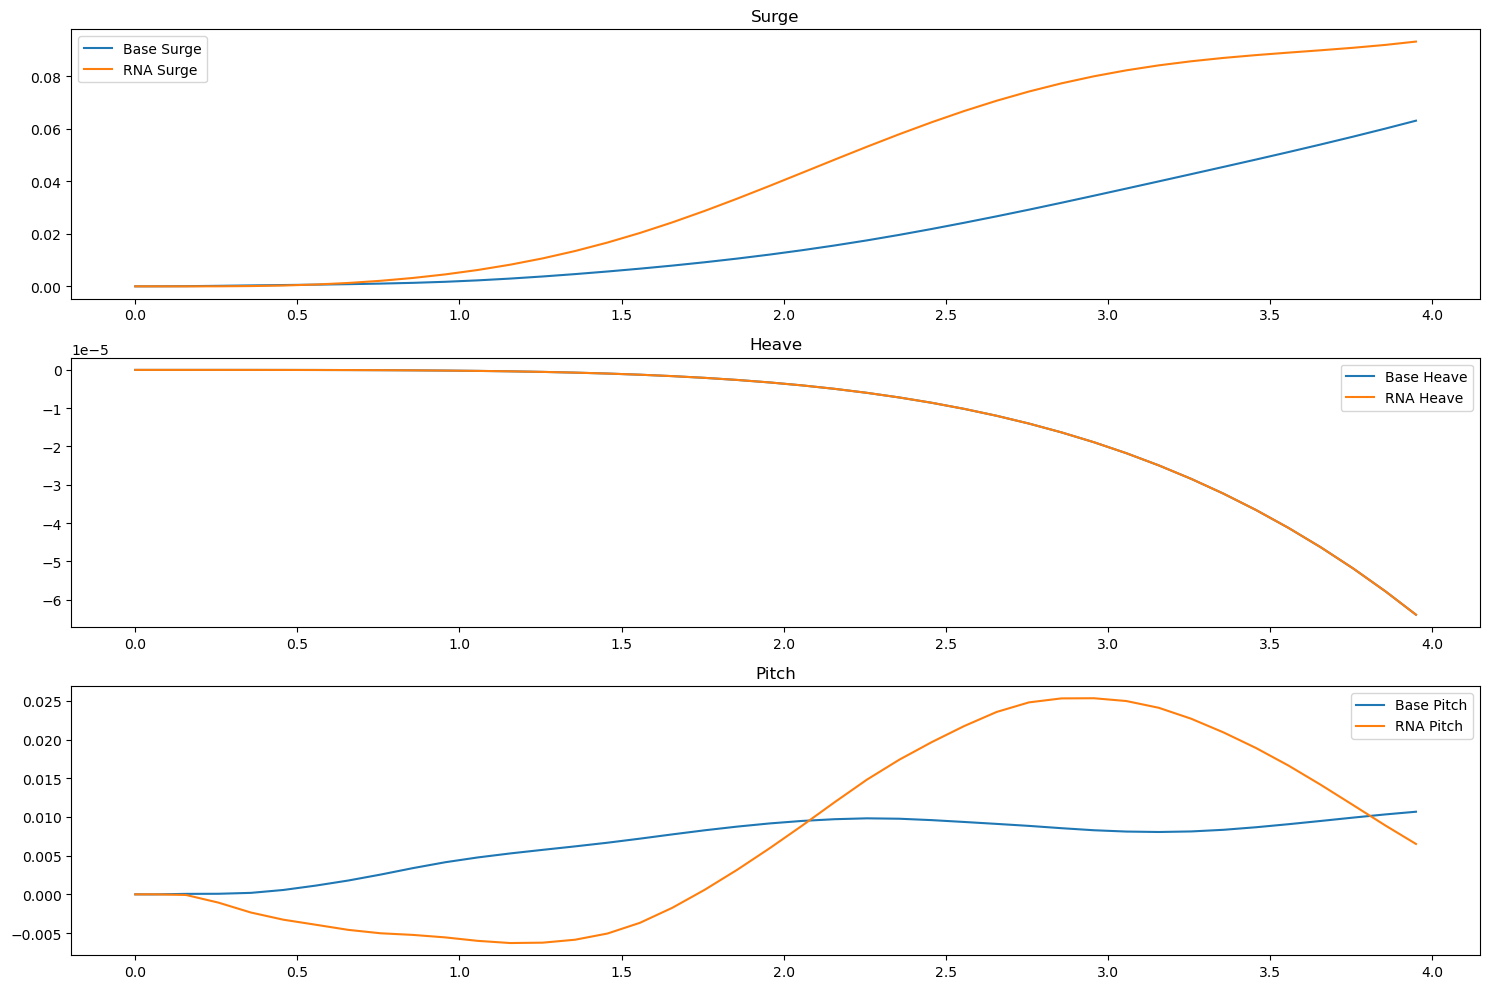

In [73]:
# ==============================================================================
# CELL 8: FULL FEM TIME DOMAIN SOLVE
# ==============================================================================
"""
DESCRIPTION:
This cell performs the non-linear time-domain simulation of the fully flexible offshore wind turbine under combined wind, wave, and current loading.

PHYSICS:
- Solves the second-order matrix differential equation: M*q'' + C*q' + K*q = F_hydro + F_aero + F_moor.
- The equation is cast into first-order state-space form [q, qdot].
- Captures relative velocity formulations for aerodynamic thrust and hydrodynamic drag.
- Captures non-linear mooring restoring forces updated at each time step.

INPUTS & ASSUMPTIONS (CHECK THESE VALUES):
- Initial Conditions: `q0 = np.zeros(2*ndofs)` (System starts at rest in the undisplaced position).
- Time span: `tspan` from 0 to `TDur-1` with step `0.05`s.
- Solvers tolerances: `rtol=1e-2` (1%), `atol=1e-3` (1mm).
- Assumption: The analytical Jacobian uses linear structural matrices and ignores the small non-linearities of the mooring system for solver speed-up.

OUTPUTS:
- `sol` : The solution object containing time histories of nodal displacements (surge, heave, pitch) and velocities.
- Plots comparing RNA vs Base kinematics and environmental inputs.

NUMERICAL METHODS:
- Runge-Kutta/Radau implicit ODE solver (`scipy.integrate.solve_ivp` with `method='Radau'`) handles the stiff differential equations.
- An analytical Jacobian matrix (`Jacobian_matrix`) is pre-computed and provided to the solver, significantly accelerating the implicit integration.
- Matrix inversion (`np.linalg.inv(M)`) is pre-computed outside the time-loop to avoid solving linear systems at every time step.
"""
udofs, vdofs = np.arange(0, ndofs), np.arange(ndofs, 2*ndofs)
q0 = np.zeros(2*ndofs)

tf = timeInfo['TDur'] - 1
tspan = np.arange(0, tf, 0.05)

zn_sub = zn[zn <= 0]
nodal_uwave = np.array([[np.interp(z, waves['z'], waves['u'][i]) for z in zn_sub] for i in range(len(waves['t']))])

def uwave(t): return np.array([np.interp(t, waves['t'], nodal_uwave[:, i]) for i in range(len(zn_sub))])
def pbase(t): return np.interp(t, waves['t'], [np.interp(draft, waves['z'], waves['phi'][i]) for i in range(len(waves['t']))])
def V_hub(t): return np.interp(t, wind['t'], wind['V_hub'])

# Pre-invert M for speed
M_inv = np.linalg.inv(M)

Fz, Fw, Fm = np.zeros(ndofs), np.zeros(ndofs), np.zeros(ndofs)
idx = vdofs[0::3][0:len(zn_sub)]
qwave = np.zeros(2*ndofs)

# --- THE MISSING ODEFUN ---
def odefun(t, q):
    qwave[idx] = uwave(t)
    urel = q[vdofs] - qwave[vdofs]
    vrel = q[vdofs[-3]] - V_hub(t)
    
    Fz[1] = np.pi*R_buoy_key[0]**2 * pbase(t)
    Fw[-3] = np.interp(vrel, thrust_table['x'], thrust_table['y'])*1e3
    
    Fmxl, Fmzl, Fmxr, Fmzr = Fmoor(q[udofs][6])
    Fm[Fair_idx*3] = Fmxr + Fmxl
    Fm[Fair_idx*3+1] = Fmzl + Fmzr
    Fm[Fair_idx*3+2] = 5.2*Fmzl - 5.2*Fmzr
    
    # Accelerated calculation using M_inv
    force_vector = -Fz + Fw - np.dot(D, urel * np.abs(urel)) + L_cur - np.dot(K, q[udofs]) + Fm - np.dot(C, q[vdofs])
    ud = np.dot(M_inv, force_vector)
    return np.append(q[vdofs], ud)

# --- PRE-COMPUTE THE EXACT LINEAR JACOBIAN MATRIX ---
print("Assembling analytical Jacobian to accelerate solver...")
I_mat = np.eye(ndofs)
Z_mat = np.zeros((ndofs, ndofs))
J_top = np.hstack((Z_mat, I_mat))
# We use the structural matrices for the Jacobian, ignoring the small mooring non-linearities
J_bot = np.hstack((-np.dot(M_inv, K), -np.dot(M_inv, C)))
Jacobian_matrix = np.vstack((J_top, J_bot))

print("Solving Non-linear FEM Time-Domain... This will be fast!")
sol = scp.solve_ivp(
    fun=odefun, 
    t_span=[tspan[0], tspan[-1]], 
    y0=q0, 
    method='Radau', 
    max_step=0.1,
    jac=Jacobian_matrix,  # <--- MAGIC KEY 1: Analytical Jacobian
    rtol=1e-2,            # <--- MAGIC KEY 2: Relaxed relative tolerance (1%)
    atol=1e-3             # <--- MAGIC KEY 3: Relaxed absolute tolerance (1mm)
)

# Plotting the main time history
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
axs[0].plot(sol.t, sol.y[udofs[0]], label='Base Surge')
axs[0].plot(sol.t, sol.y[udofs[-3]], label='RNA Surge')
axs[0].legend(); axs[0].set_title('Surge')

axs[1].plot(sol.t, sol.y[udofs[1]], label='Base Heave')
axs[1].plot(sol.t, sol.y[udofs[-2]], label='RNA Heave')
axs[1].legend(); axs[1].set_title('Heave')

axs[2].plot(sol.t, np.rad2deg(sol.y[udofs[2]]), label='Base Pitch')
axs[2].plot(sol.t, np.rad2deg(sol.y[udofs[-1]]), label='RNA Pitch')
axs[2].legend(); axs[2].set_title('Pitch')
plt.tight_layout(); plt.show()

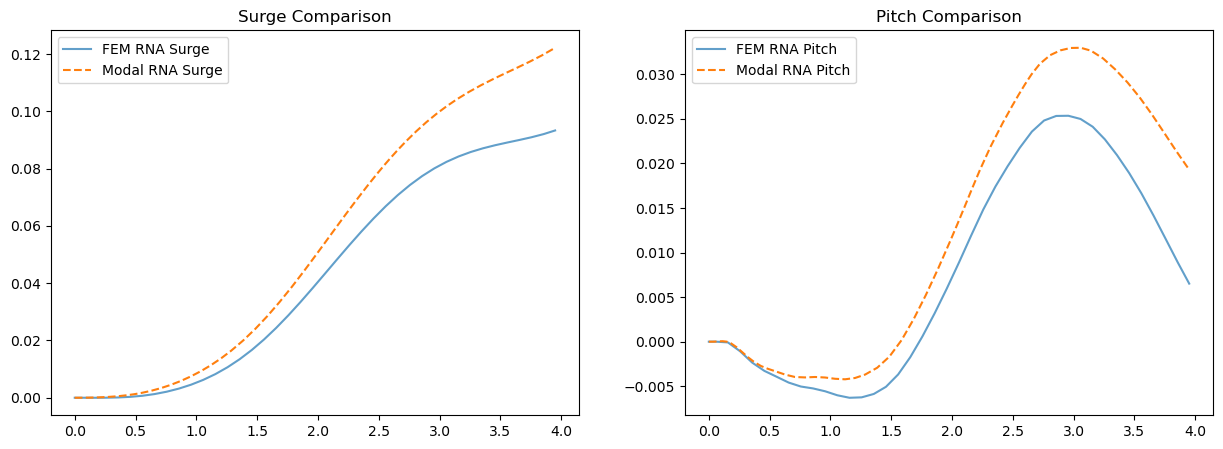

In [74]:
# ==============================================================================
# CELL 9: MODAL ANALYSIS (REDUCED ORDER MODEL)
# ==============================================================================
"""
DESCRIPTION:
This cell computes the structural mode shapes (eigenvectors) and natural frequencies (eigenvalues), and simulates the system using a Reduced Order Model (ROM) based on modal superposition.

PHYSICS:
- Extracts the undamped free-vibration modes of the structure from the generalized eigenvalue problem: (K - w^2*M) * phi = 0.
- Modal Superposition transforms physical coordinates `q` into modal coordinates `Am`, decoupling the linear components of the system.

INPUTS & ASSUMPTIONS (CHECK THESE VALUES):
- `nMode = nn*3` : Number of modes retained (here it retains all modes, but typically ROMs truncate higher-order modes).
- Modal Damping: `Cm[iMode] = 0.01*Mm[iMode] + 0.01*Km[iMode]` (Rayleigh damping projected into modal space).
- Assumption: Mode shapes remain constant over time (linear structural assumption).

OUTPUTS:
- Natural frequencies `f` and mode shapes `vr_sorted`.
- `q_sol` : Time-domain solution in modal coordinates.
- `U_F` : Reconstructed physical displacements from modal responses.
- Plots comparing the FEM solution vs the Modal Superposition (ROM) solution.

NUMERICAL METHODS:
- Generalized Eigenvalue decomposition (`np.linalg.eig(mat)`) finds natural frequencies and mode shapes.
- ODE Integration (`solve_ivp`) solves the reduced modal equations of motion.
- Matrix projection (`PHI.T @ F_vec`) maps non-linear physical forces into the modal domain at each time step.
"""
mat = np.dot(M_inv, K)
w2, vr = np.linalg.eig(mat)
w_freq = np.sqrt(np.abs(w2.real))
f = w_freq / (2*np.pi)

idx_sort = f.argsort()
f = f[idx_sort]
vr_sorted = vr[:, idx_sort]

nMode = nn*3
PHI = vr_sorted[:, 0:nMode]

Mm, Km, Cm = np.zeros(nMode), np.zeros(nMode), np.zeros(nMode)
for iMode in range(nMode):
    Mm[iMode] = PHI[:,iMode].T @ M @ PHI[:,iMode]
    Km[iMode] = PHI[:,iMode].T @ K @ PHI[:,iMode]
    Cm[iMode] = 0.01*Mm[iMode] + 0.01*Km[iMode]

def qdot(t, q):
    qwave[idx] = uwave(t)
    U_F = np.sum(PHI*q[0:nMode], 1)
    V_F = np.sum(PHI*q[nMode:2*nMode], 1)
    
    urel = V_F - qwave[vdofs]
    vrel = V_F[-3] - V_hub(t)
    
    Fz[1] = np.pi*R_buoy_key[0]**2 * pbase(t)
    Fw[-3] = np.interp(vrel, thrust_table['x'], thrust_table['y'])*1e3
    
    Fmxl, Fmzl, Fmxr, Fmzr = Fmoor(U_F[6])
    Fm[Fair_idx*3] = Fmxr + Fmxl
    Fm[Fair_idx*3+1] = Fmzl + Fmzr
    Fm[Fair_idx*3+2] = 5.2*Fmzl - 5.2*Fmzr
    
    F_vec = -Fz + Fw - np.dot(D, (urel * np.abs(urel))) + L_cur + Fm
    Am = (PHI.T @ F_vec - (Km * q[0:nMode] + Cm * q[nMode:2*nMode])) / Mm
    return np.append(q[nMode:2*nMode], Am)

q0_modal = np.zeros(2*nMode)
q_sol = scp.solve_ivp(fun=qdot, t_span=[tspan[0], tspan[-1]], y0=q0_modal, method='Radau', max_step=0.1)

# Reconstruct the physical coordinates from the modal coordinates
U_F = np.zeros((len(q_sol.t), len(PHI[:,0])))
for iMode in range(nMode):
    for it in range(len(q_sol.t)):
        U_F[it,:] += PHI[:,iMode] * q_sol.y[iMode][it]

# Plot Comparison (FEM vs Modal)
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].plot(sol.t, sol.y[udofs[-3]], label='FEM RNA Surge', alpha=0.7)
axs[0].plot(q_sol.t, U_F[:, -3], '--', label='Modal RNA Surge')
axs[0].legend(); axs[0].set_title('Surge Comparison')

axs[1].plot(sol.t, np.rad2deg(sol.y[udofs[-1]]), label='FEM RNA Pitch', alpha=0.7)
axs[1].plot(q_sol.t, np.rad2deg(U_F[:, -1]), '--', label='Modal RNA Pitch')
axs[1].legend(); axs[1].set_title('Pitch Comparison')
plt.show()

Solving Pitch Decay...
Solving Heave Decay...


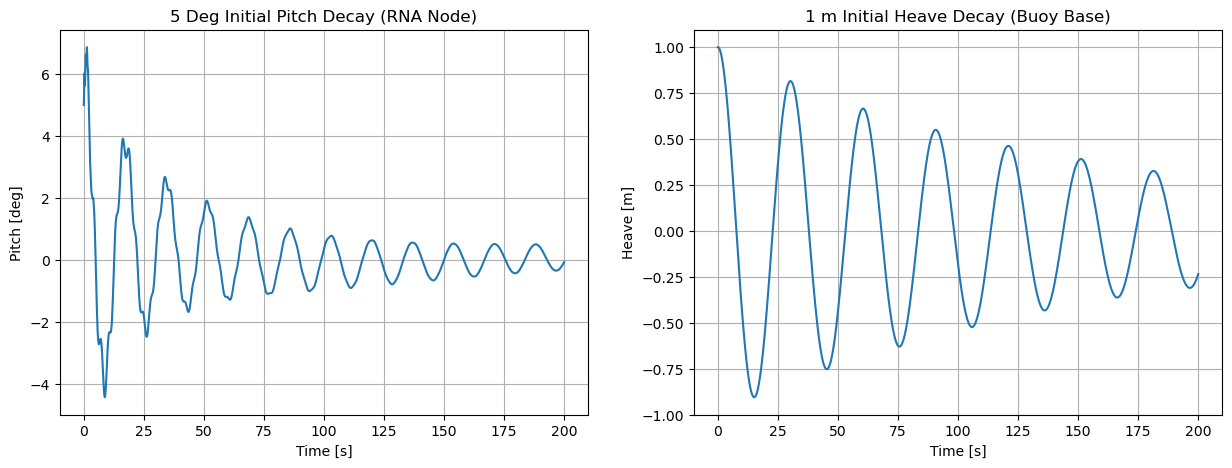

Total Notebook Execution Time: 18.54 seconds


In [75]:
# ==============================================================================
# CELL 10: FREE DECAY TESTS (PITCH & HEAVE)
# ==============================================================================
"""
DESCRIPTION:
This cell performs free decay simulations to analyze the unforced, damped transient response of the system in the Pitch and Heave degrees of freedom.

PHYSICS:
- Free decay involves releasing the structure from an initial offset in calm water/no wind conditions.
- The response envelope highlights the system's natural frequencies and effective damping (radiation + viscous drag + structural).

INPUTS & ASSUMPTIONS (CHECK THESE VALUES):
- Pitch Decay Initial Conditions: 5 degrees rigid-body pitch rotation (`du0 = np.deg2rad(5)`). Nodes are displaced linearly proportional to height.
- Heave Decay Initial Conditions: 1 meter rigid-body vertical offset (`q0_heave[udofs[1::3]] = 1.0`).
- Time span: Simulated over `200` seconds.
- Assumption: Environmental forces (Wind `Fw`, Waves `qwave`, Current `L_cur`) are implicitly set to zero by not evaluating them inside `odefun_decay`.

OUTPUTS:
- Time-series plots of Pitch and Heave decay motions.
- Total notebook execution time printout.

NUMERICAL METHODS:
- Implicit ODE Solver (`solve_ivp` with `method='Radau'`) integrates the unforced equations of motion from the non-zero initial state.
"""
def odefun_decay(t, q):             
    urel = q[vdofs] 
    Fmxl, Fmzl, Fmxr, Fmzr = Fmoor(q[udofs][6])
    Fm[Fair_idx*3] = Fmxr + Fmxl
    Fm[Fair_idx*3+1] = Fmzl + Fmzr
    Fm[Fair_idx*3+2] = 5.2*Fmzl - 5.2*Fmzr
        
    ud = np.dot(M_inv, -np.dot(D, urel*np.abs(urel)) - np.dot(K, q[udofs]) + Fm - np.dot(C, q[vdofs]))
    return np.append(q[vdofs], ud)

# --- 5 DEG PITCH DECAY ---
q0_pitch = np.zeros(2*ndofs)
du0 = np.deg2rad(5)
q0_pitch[udofs[2::3]] = du0
q0_pitch[udofs[0::3]] = du0 * zn - (du0 * zn)[0]

print("Solving Pitch Decay...")
sol_pitch = scp.solve_ivp(fun=odefun_decay, t_span=[0, 200], y0=q0_pitch, method='Radau', max_step=0.1)

# --- 1 METER HEAVE DECAY ---
q0_heave = np.zeros(2*ndofs)
q0_heave[udofs[1::3]] = 1.0

print("Solving Heave Decay...")
sol_heave = scp.solve_ivp(fun=odefun_decay, t_span=[0, 200], y0=q0_heave, method='Radau', max_step=0.1)

# Plot Results
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].plot(sol_pitch.t, np.rad2deg(sol_pitch.y[udofs[-1]]))
axs[0].set_title('5 Deg Initial Pitch Decay (RNA Node)')
axs[0].set_xlabel('Time [s]'); axs[0].set_ylabel('Pitch [deg]'); axs[0].grid()

axs[1].plot(sol_heave.t, sol_heave.y[udofs[1]])
axs[1].set_title('1 m Initial Heave Decay (Buoy Base)')
axs[1].set_xlabel('Time [s]'); axs[1].set_ylabel('Heave [m]'); axs[1].grid()
plt.show()

print(f"Total Notebook Execution Time: {time.time() - start_time:.2f} seconds")